# 16 — Sequence models, deep dive: architecture, the unsupervised ceiling, and where the signal lives

Notebooks 05 & 07 showed that on **CS2CD** the cheat signal is *not* in per-tick marginals
(`yaw` separates legit/cheat at only rank-biserial r ≈ 0.088) — it lives in **temporal
patterns over windows**. This notebook brings out the model that exploits those patterns: a
**sequence autoencoder** trained only on legit play, which flags cheat chunks by high
reconstruction error.

We ask three questions, all on the GPU (RTX 3070), all live:

1. **Is the LSTM the right backbone?** Head-to-head vs a dilated-conv **TCN-AE** and a
   self-attention **Transformer-AE**, across *three* eval settings — synthetic GTA cheats,
   **real recorded** GTA cheats, and the **external CS2** dataset.
2. **Are the modest real-data AUCs real, or just a lucky/unlucky train/test split?** We
   *measure* it (overlapping vs strict held-out-legit baseline) instead of asserting.
3. **Is unsupervised reconstruction the ceiling — would labels help?** CS2's 10 players finally
   make a **supervised** sequence classifier viable (GTA's 1 cheat player could not), so we
   test the supervised lever directly.

> Tutorial notebook — verbose by design. Training is seeded; absolute AUCs may wobble ~±0.01
> run-to-run (cuDNN), but the *ranking and conclusions* are stable.

## A — Setup & experimental design

Three autoencoders, **same** training loop, **same** 64-event chunks, **same** chunk-AUC metric
— only the backbone changes:

| Backbone | Inductive bias | Params (8-ch GTA) |
|---|---|---|
| **LSTM-AE** | recurrence / memory | ~196k |
| **TCN-AE** | dilated 1-D convolutions (wide receptive field, no recurrence) | ~78k |
| **Transformer-AE** | self-attention + learned positional encoding | ~207k |

All train on **legit chunks only** (the AE learns the "normal" manifold); cheat chunks are
unseen at train time and surface as high reconstruction error. We reuse the exact functions
behind `scripts/compare_architectures.py` and `scripts/benchmark_cs2cd_ae.py` so the notebook
matches the committed pipeline.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from pipeline.explainability import CHANNEL_NAMES, per_channel_reconstruction_error
from pipeline.models.lstm_ae import LSTMAutoencoder, score_sequences
from pipeline.models.tcn_ae import TCNAutoencoder
from pipeline.models.transformer_ae import TransformerAutoencoder
from pipeline.sequences.dataset import EventSequenceDataset
from pipeline.sequences.preprocessing import (
    EVENT_FEATURE_DIM,
    apply_normalizer,
    fit_normalizer,
    session_to_event_tensor,
)
from scripts.benchmark_cs2cd_ae import CS2_FEATURES, _load_streams, _stack_chunks
from scripts.compare_architectures import (
    CHEATS,
    CHUNK,
    RAW,
    SEED,
    STRIDE,
    SYN,
    _build_loaders,
    _chunk_auc,
    _device,
    _eval_chunks,
)

DEV = _device()
torch.manual_seed(SEED)
np.random.seed(SEED)
print("device:", DEV, "| chunk:", CHUNK, "| channels (GTA):", CHANNEL_NAMES)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


def builders(feature_dim):
    return {
        "LSTM-AE": lambda: LSTMAutoencoder(
            feature_dim=feature_dim, hidden_dim=64, bottleneck_dim=16, num_layers=2
        ),
        "TCN-AE": lambda: TCNAutoencoder(
            feature_dim=feature_dim, seq_len=CHUNK, hidden_dim=32, bottleneck_dim=16
        ),
        "Transformer-AE": lambda: TransformerAutoencoder(
            feature_dim=feature_dim,
            seq_len=CHUNK,
            d_model=64,
            nhead=4,
            num_layers=2,
            bottleneck_dim=16,
        ),
    }


COLORS = {"LSTM-AE": "#4c78a8", "TCN-AE": "#54a24b", "Transformer-AE": "#e94560"}


def fit_ae(model, tl, vl, epochs=25, lr=1e-3):
    """Generic AE training loop that ALSO records per-epoch history (for curves).
    Mirrors scripts.compare_architectures.train_ae + best-val weight restore."""
    model = model.to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lf = nn.MSELoss()
    hist = {"train": [], "val": []}
    best = float("inf")
    best_state = None
    for _ in range(epochs):
        model.train()
        tot = n = 0.0
        for b in tl:
            b = b.to(DEV)
            opt.zero_grad()
            loss = lf(model(b), b)
            loss.backward()
            opt.step()
            tot += loss.item() * len(b)
            n += len(b)
        tr = tot / max(n, 1)
        model.eval()
        vt = vn = 0.0
        with torch.no_grad():
            for b in vl:
                b = b.to(DEV)
                vt += lf(model(b), b).item() * len(b)
                vn += len(b)
        va = vt / max(vn, 1)
        hist["train"].append(tr)
        hist["val"].append(va)
        if va < best:
            best = va
            best_state = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }
    if best_state:
        model.load_state_dict(best_state)
    params = int(sum(p.numel() for p in model.parameters()))
    return model, hist, params

device: cuda | chunk: 64 | channels (GTA): ['dt', 'dx', 'dy', 'is_mouse_move', 'is_mouse_click_press', 'is_mouse_scroll', 'is_key_press', 'is_key_release']


## B — Headline comparison, GPU-live

Train the three GTA backbones **once** on real legit chunks (`data/raw`), then score chunk-AUC on
**synthetic** and **real** cheats. Separately train them on CS2 legit (4-channel mouse stream) for
the external column. The result is 3 backbones × 3 settings = 9 measurements.

In [2]:
EPOCHS = 25
# --- GTA: train once on real legit, eval on synthetic + real cheat sets ---
tl, vl, stats = _build_loaders()
gta_models = {}
for name, build in builders(EVENT_FEATURE_DIM).items():
    torch.manual_seed(SEED)
    m, hist, params = fit_ae(build(), tl, vl, EPOCHS)
    gta_models[name] = {"model": m, "hist": hist, "params": params}
    print(f"{name:16s} params={params:>7d}  val_loss={hist['val'][-1]:.4f}")

legit_syn, cheat_syn = _eval_chunks(stats, SYN)
legit_raw, cheat_raw = _eval_chunks(stats, RAW)
print("synthetic eval chunks:", len(legit_syn), {c: len(cheat_syn[c]) for c in CHEATS})
print("real eval chunks:     ", len(legit_raw), {c: len(cheat_raw[c]) for c in CHEATS})

LSTM-AE          params= 196120  val_loss=0.5792


TCN-AE           params=  78488  val_loss=0.4729


Transformer-AE   params= 207320  val_loss=0.6196


synthetic eval chunks: 120583 {'aimbot': 4480, 'triggerbot': 1314, 'macro': 538}
real eval chunks:      29976 {'aimbot': 2767, 'triggerbot': 2604, 'macro': 2200}


In [3]:
# --- CS2: train the same three backbones on CS2 legit (4-ch), eval cheat AUC ---
streams = _load_streams()  # list[(label, (N,4))]
legit_cs = [t for lab, t in streams if lab == 0]
cheat_cs = [t for lab, t in streams if lab == 1]
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(legit_cs))
nval = max(1, int(round(len(legit_cs) * 0.15)))
vidx = set(perm[:nval].tolist())
tr = [legit_cs[i] for i in range(len(legit_cs)) if i not in vidx]
va = [legit_cs[i] for i in range(len(legit_cs)) if i in vidx]
cs_stats = fit_normalizer(tr)


class _CK(torch.utils.data.Dataset):
    def __init__(self, a):
        self.a = a

    def __len__(self):
        return len(self.a)

    def __getitem__(self, i):
        return torch.from_numpy(self.a[i]).float()


tl_cs = DataLoader(
    _CK(_stack_chunks([apply_normalizer(t, cs_stats) for t in tr], STRIDE)),
    batch_size=256,
    shuffle=True,
)
vl_cs = DataLoader(
    _CK(_stack_chunks([apply_normalizer(t, cs_stats) for t in va], CHUNK)),
    batch_size=256,
)
legit_eval_cs = _stack_chunks([apply_normalizer(t, cs_stats) for t in legit_cs], CHUNK)
cheat_eval_cs = _stack_chunks([apply_normalizer(t, cs_stats) for t in cheat_cs], CHUNK)

cs_auc = {}
for name, build in builders(len(CS2_FEATURES)).items():
    torch.manual_seed(SEED)
    m, _, _ = fit_ae(build(), tl_cs, vl_cs, EPOCHS)
    ls = score_sequences(m, legit_eval_cs, device=DEV)
    cs = score_sequences(m, cheat_eval_cs, device=DEV)
    y = np.r_[np.zeros(len(ls)), np.ones(len(cs))]
    cs_auc[name] = roc_auc_score(y, np.r_[ls, cs])
    print(f"{name:16s} CS2 cheat AUC = {cs_auc[name]:.3f}")
print(
    "CS2 eval chunks:",
    len(legit_eval_cs),
    "legit /",
    len(cheat_eval_cs),
    "cheat | players=10",
)

LSTM-AE          CS2 cheat AUC = 0.723


TCN-AE           CS2 cheat AUC = 0.722


Transformer-AE   CS2 cheat AUC = 0.722
CS2 eval chunks: 390 legit / 390 cheat | players=10


In [4]:
# --- Assemble the 3x3 results table ---
rows = []
for name in gta_models:
    a_syn = _chunk_auc(gta_models[name]["model"], legit_syn, cheat_syn)
    a_raw = _chunk_auc(gta_models[name]["model"], legit_raw, cheat_raw)
    rows.append(
        {
            "model": name,
            "params": gta_models[name]["params"],
            "synthGTA_aim": a_syn["aimbot"],
            "synthGTA_trig": a_syn["triggerbot"],
            "synthGTA_macro": a_syn["macro"],
            "realGTA_aim": a_raw["aimbot"],
            "realGTA_trig": a_raw["triggerbot"],
            "realGTA_macro": a_raw["macro"],
            "CS2": cs_auc[name],
        }
    )
res = pd.DataFrame(rows).set_index("model")
gta_models["__res__"] = res  # stash for later cells
res.round(3)

,params,synthGTA_aim,synthGTA_trig,synthGTA_macro,realGTA_aim,realGTA_trig,realGTA_macro,CS2
model,,,,,,,,
LSTM-AE,196120,0.804,0.940,0.614,0.525,0.603,0.566,0.723
TCN-AE,78488,0.731,0.842,0.572,0.512,0.590,0.559,0.722
Transformer-AE,207320,0.817,0.958,0.608,0.527,0.603,0.566,0.722


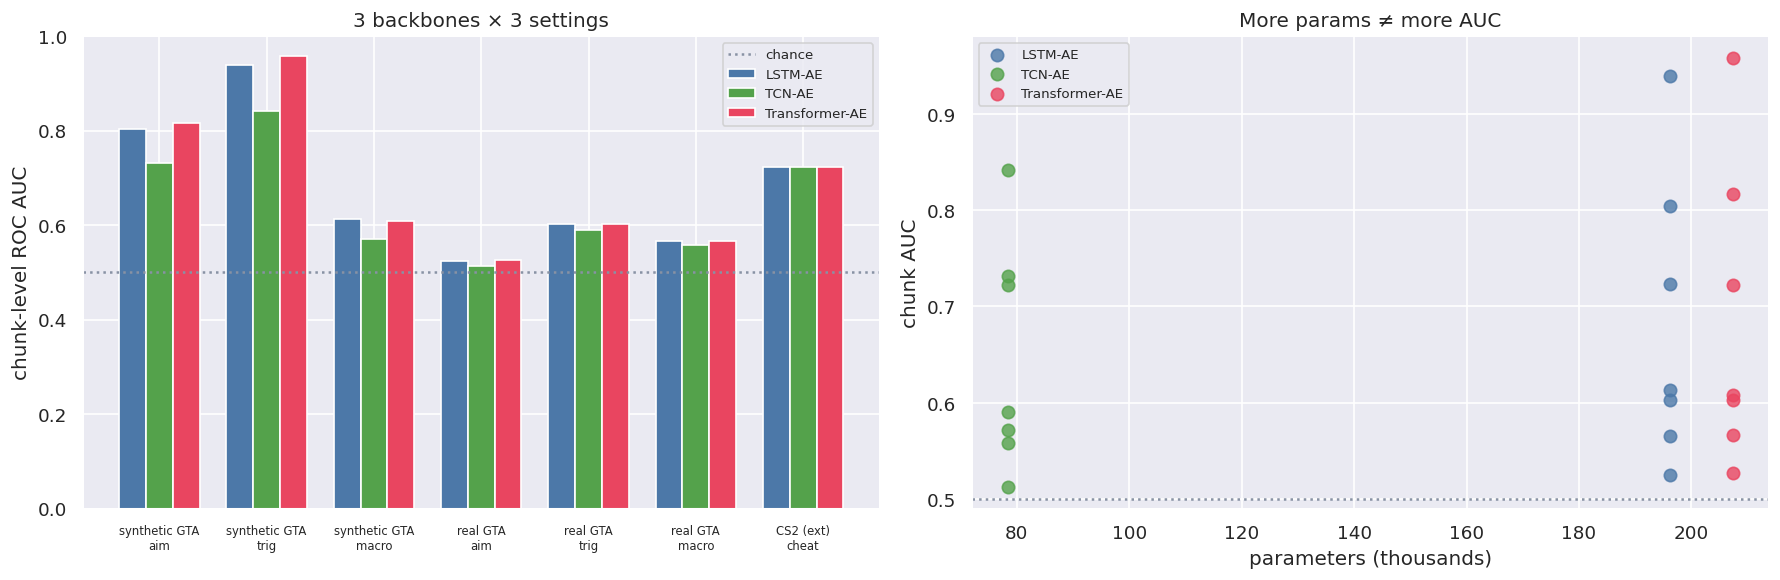

Max backbone spread (max-min across the 3 backbones), per setting:
  synthetic GTA    max=0.116  mean=0.081
  real GTA         max=0.014  mean=0.012
  CS2 (ext)        max=0.001  mean=0.001


In [5]:
# --- Visualise: grouped bars per setting + params-vs-AUC scatter ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
settings = {
    "synthetic GTA": ["synthGTA_aim", "synthGTA_trig", "synthGTA_macro"],
    "real GTA": ["realGTA_aim", "realGTA_trig", "realGTA_macro"],
    "CS2 (ext)": ["CS2"],
}
labels = []
xs = []
i = 0
for s, cols in settings.items():
    for col in cols:
        xs.append(i)
        labels.append(f"{s}\n{col.split('_')[-1] if '_' in col else 'cheat'}")
        i += 1
w = 0.25
for j, name in enumerate(res.index):
    vals = [res.loc[name, c] for cols in settings.values() for c in cols]
    axes[0].bar(np.array(xs) + (j - 1) * w, vals, w, label=name, color=COLORS[name])
axes[0].axhline(0.5, ls=":", c="#8892a4", label="chance")
axes[0].set_xticks(xs)
axes[0].set_xticklabels(labels, fontsize=7)
axes[0].set_ylabel("chunk-level ROC AUC")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].set_title("3 backbones × 3 settings")

# scatter: params vs AUC (all 9 points)
for name in res.index:
    pts = [res.loc[name, c] for cols in settings.values() for c in cols]
    axes[1].scatter(
        [res.loc[name, "params"] / 1e3] * len(pts),
        pts,
        s=55,
        color=COLORS[name],
        label=name,
        alpha=0.8,
    )
axes[1].axhline(0.5, ls=":", c="#8892a4")
axes[1].set_xlabel("parameters (thousands)")
axes[1].set_ylabel("chunk AUC")
axes[1].set_title("More params ≠ more AUC")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    ROOT / "reports" / "figures" / "arch_comparison_synthesis.png",
    dpi=110,
    bbox_inches="tight",
)
plt.show()
# Backbone spread = max-min ACROSS THE 3 BACKBONES, holding the cheat-type fixed (isolates
# architecture effect from the much larger cheat-type effect).
print("Max backbone spread (max-min across the 3 backbones), per setting:")
for s, cols in settings.items():
    per_col = [res[c].max() - res[c].min() for c in cols]
    print(f"  {s:16s} max={max(per_col):.3f}  mean={np.mean(per_col):.3f}")

**Read-out.** On **real GTA** and **CS2** the three backbones are tied to within run-to-run noise
(backbone spread ≈ 0.01 and ≈ 0.001). On **synthetic** the only gap is the cheap 78k-param TCN
trailing by ~0.1, while **LSTM ≈ Transformer** despite the Transformer having ~2.6× the params —
so no backbone is a consistent winner and the params-vs-AUC scatter is essentially flat.
**Capacity is not the bottleneck.** What *does* swing the AUC is the setting (synthetic ≫ real GTA),
i.e. the **data**, not the architecture.

## C — Deeper than a bar chart

Why are the AUCs what they are? Four lenses on the trained LSTM-AE (+ training curves for all three).

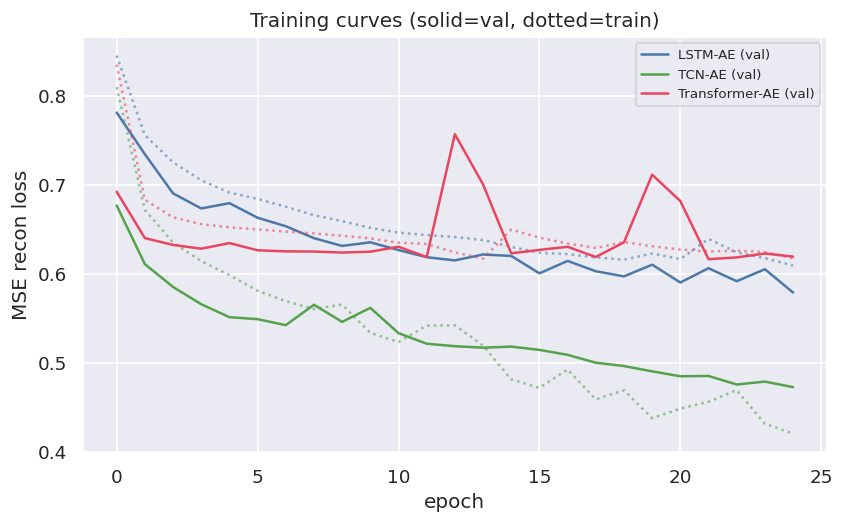

In [6]:
# Training curves (all three backbones)
fig, ax = plt.subplots(figsize=(8, 4.5))
for name in gta_models:
    if name == "__res__":
        continue
    h = gta_models[name]["hist"]
    ax.plot(h["val"], color=COLORS[name], label=f"{name} (val)")
    ax.plot(h["train"], color=COLORS[name], ls=":", alpha=0.6)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE recon loss")
ax.set_title("Training curves (solid=val, dotted=train)")
ax.legend(fontsize=8)
plt.show()

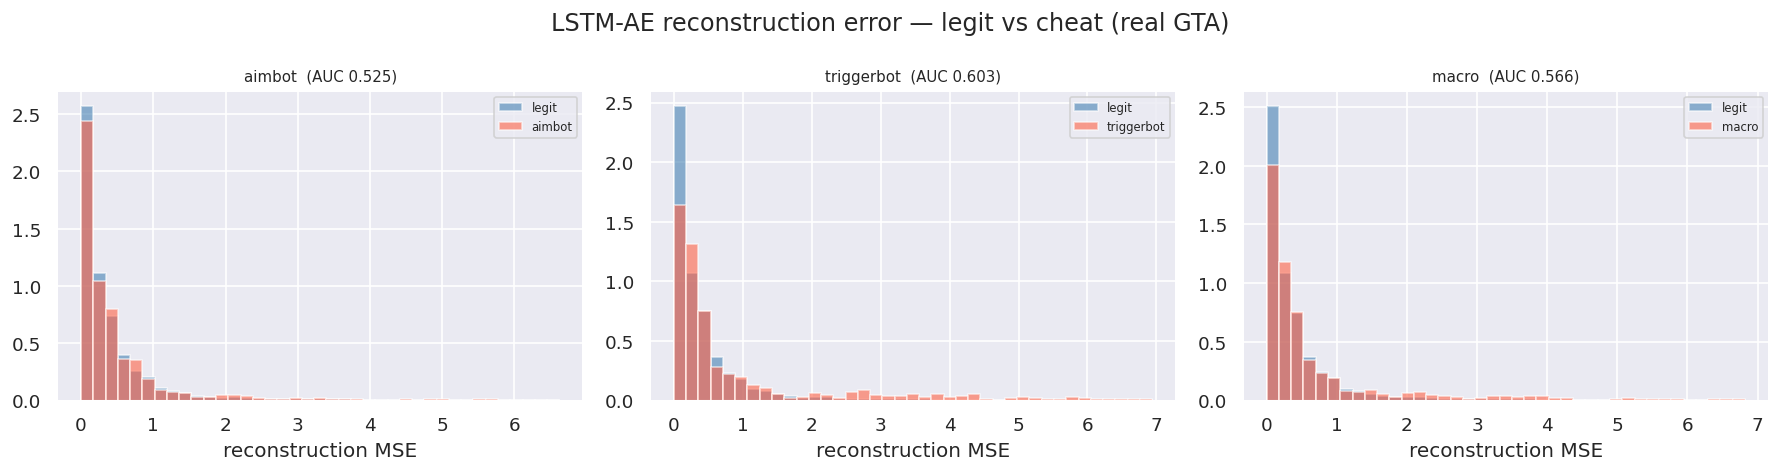

In [7]:
# Reconstruction-error distributions: legit vs each cheat type (LSTM-AE, real GTA)
m = gta_models["LSTM-AE"]["model"]
ls = score_sequences(m, legit_raw, device=DEV)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, CHEATS):
    cs = score_sequences(m, cheat_raw[c], device=DEV)
    hi = np.percentile(np.r_[ls, cs], 99)
    bins = np.linspace(0, hi, 40)
    ax.hist(ls, bins=bins, alpha=0.6, density=True, color="steelblue", label="legit")
    ax.hist(cs, bins=bins, alpha=0.6, density=True, color="tomato", label=c)
    ax.set_title(
        f"{c}  (AUC {roc_auc_score(np.r_[np.zeros(len(ls)),np.ones(len(cs))], np.r_[ls,cs]):.3f})",
        fontsize=9,
    )
    ax.set_xlabel("reconstruction MSE")
    ax.legend(fontsize=7)
fig.suptitle("LSTM-AE reconstruction error — legit vs cheat (real GTA)")
fig.tight_layout()
plt.show()

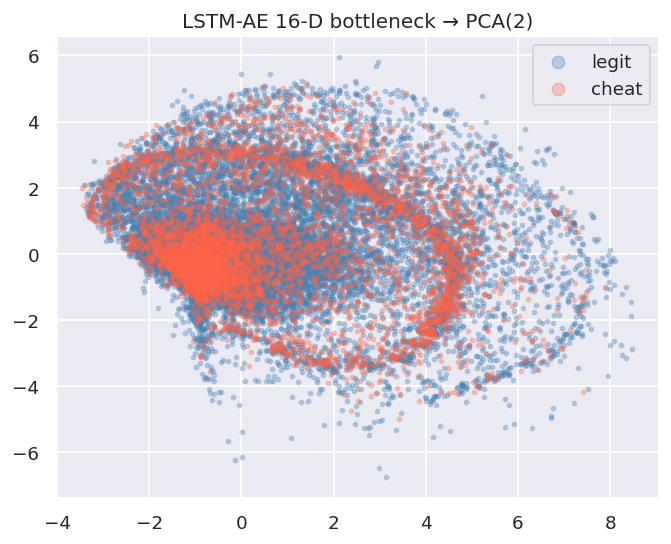

In [8]:
# Bottleneck embedding (LSTM-AE.encode) projected to 2-D, legit vs cheat (real GTA, pooled cheats)
cheat_all = np.concatenate([cheat_raw[c] for c in CHEATS if len(cheat_raw[c])])
with torch.no_grad():
    z_l = m.encode(torch.from_numpy(legit_raw).float().to(DEV)).cpu().numpy()
    z_c = m.encode(torch.from_numpy(cheat_all).float().to(DEV)).cpu().numpy()
Z = PCA(n_components=2, random_state=SEED).fit_transform(np.r_[z_l, z_c])
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(
    Z[: len(z_l), 0], Z[: len(z_l), 1], s=6, alpha=0.3, color="steelblue", label="legit"
)
ax.scatter(
    Z[len(z_l) :, 0], Z[len(z_l) :, 1], s=6, alpha=0.3, color="tomato", label="cheat"
)
ax.set_title("LSTM-AE 16-D bottleneck → PCA(2)")
ax.legend(markerscale=3)
plt.show()

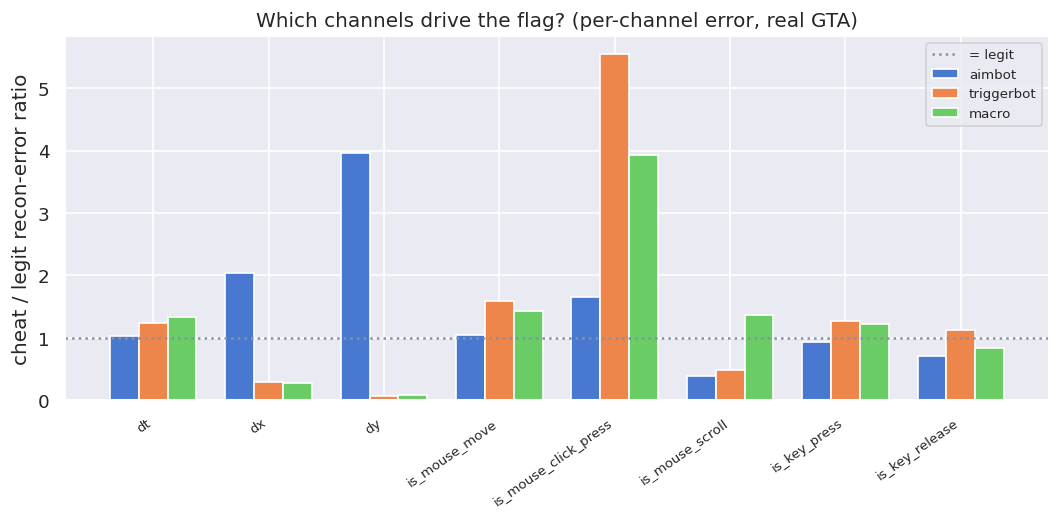

In [9]:
# Per-channel reconstruction error: which of the 8 input channels drives each cheat?
fig, ax = plt.subplots(figsize=(9, 4.5))
base = per_channel_reconstruction_error(m, legit_raw).mean(0)
x = np.arange(len(CHANNEL_NAMES))
w = 0.25
for j, c in enumerate(CHEATS):
    if not len(cheat_raw[c]):
        continue
    ratio = per_channel_reconstruction_error(m, cheat_raw[c]).mean(0) / (base + 1e-9)
    ax.bar(x + (j - 1) * w, ratio, w, label=c)
ax.axhline(1.0, ls=":", c="#8892a4", label="= legit")
ax.set_xticks(x)
ax.set_xticklabels(CHANNEL_NAMES, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("cheat / legit recon-error ratio")
ax.set_title("Which channels drive the flag? (per-channel error, real GTA)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## D — Is it the split, or a real ceiling? Two experiments

The real-GTA AUCs (~0.55–0.63) are far below synthetic. Two hypotheses, both testable:

1. **Optimistic split.** The eval's legit baseline includes the AE's *own training* sessions, so
   legit reconstructs suspiciously well → separation looks easier than it is.
2. **Unsupervised ceiling.** Reconstruction is the wrong objective; labels would help.

We measure both.

In [10]:
# D1 — split-sensitivity: overlapping-baseline vs STRICT held-out-legit baseline (real GTA)
from pipeline.adversarial.benchmark import _chunk_cheat_labels, _typed_segments

legit_paths = [
    p for p in sorted(RAW.glob("*.json")) if not _typed_segments(json.load(open(p)))
]
cheat_paths = [
    p for p in sorted(RAW.glob("*.json")) if _typed_segments(json.load(open(p)))
]
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(legit_paths))
hold = set(perm[:4].tolist())
train_paths = [legit_paths[i] for i in range(len(legit_paths)) if i not in hold]
held_paths = [legit_paths[i] for i in range(len(legit_paths)) if i in hold]
tr_tensors = [
    t
    for t in (session_to_event_tensor(json.load(open(p))) for p in train_paths)
    if len(t) >= CHUNK
]
s2 = fit_normalizer(tr_tensors)
tr_ds = EventSequenceDataset(
    [apply_normalizer(t, s2) for t in tr_tensors], CHUNK, STRIDE
)
# tiny internal val for best-weight restore
rng = np.random.default_rng(SEED)
pv = rng.permutation(len(tr_tensors))
nv = max(1, len(tr_tensors) // 6)
va_ds = EventSequenceDataset(
    [apply_normalizer(tr_tensors[i], s2) for i in pv[:nv]], CHUNK, CHUNK
)
torch.manual_seed(SEED)
m2, _, _ = fit_ae(
    LSTMAutoencoder(hidden_dim=64, bottleneck_dim=16, num_layers=2),
    DataLoader(tr_ds, batch_size=256, shuffle=True),
    DataLoader(va_ds, batch_size=256),
    EPOCHS,
)


def chunks_of(paths):
    out = []
    for p in paths:
        t = session_to_event_tensor(json.load(open(p)))
        if len(t) < CHUNK:
            continue
        nz = apply_normalizer(t, s2)
        n = len(nz) // CHUNK
        out.append(np.stack([nz[i * CHUNK : (i + 1) * CHUNK] for i in range(n)]))
    return np.concatenate(out) if out else np.empty((0, CHUNK, 8), np.float32)


all_legit = chunks_of(legit_paths)
held_legit = chunks_of(held_paths)
cbt = {c: [] for c in CHEATS}
for p in cheat_paths:
    t = session_to_event_tensor(json.load(open(p)))
    if len(t) < CHUNK:
        continue
    nz = apply_normalizer(t, s2)
    n = len(nz) // CHUNK
    ch = np.stack([nz[i * CHUNK : (i + 1) * CHUNK] for i in range(n)])
    types = _chunk_cheat_labels(json.load(open(p)), CHUNK, n)
    for c in CHEATS:
        if len(ch[types == c]):
            cbt[c].append(ch[types == c])
cbt = {
    c: (np.concatenate(v) if v else np.empty((0, CHUNK, 8), np.float32))
    for c, v in cbt.items()
}


def auc(base, ch):
    if not len(base) or not len(ch):
        return float("nan")
    a = score_sequences(m2, base, device=DEV)
    b = score_sequences(m2, ch, device=DEV)
    return roc_auc_score(np.r_[np.zeros(len(a)), np.ones(len(b))], np.r_[a, b])


split_rows = []
for c in CHEATS:
    o, h = auc(all_legit, cbt[c]), auc(held_legit, cbt[c])
    split_rows.append(
        {
            "cheat": c,
            "overlapping_baseline": round(o, 3),
            "heldout_legit_baseline": round(h, 3),
            "delta": round(h - o, 3),
        }
    )
split_df = pd.DataFrame(split_rows).set_index("cheat")
print(split_df)
print(f"\nMean |delta| across cheat types: {split_df['delta'].abs().mean():.3f}")

            overlapping_baseline  heldout_legit_baseline  delta
cheat                                                          
aimbot                     0.552                   0.546 -0.005
triggerbot                 0.629                   0.620 -0.009
macro                      0.592                   0.585 -0.007

Mean |delta| across cheat types: 0.007


**D1 verdict.** The held-out-legit baseline barely moves the AUC (|Δ| ≈ a hundredth). So the
real-GTA numbers are **not** a split artifact — the optimism from baseline overlap is negligible.
The modest AUC is the *data* (one cheat player, sparse toggled cheat spans), not the eval split.

In [11]:
# D2 — supervised lever: a SUPERVISED CS2 cheat classifier (player-held-out) vs the unsupervised AE
from scripts.benchmark_cs2cd_ae import GAP

PARQ = ROOT / "data" / "external" / "cs2cd" / "cs2cd_balanced_25000.parquet"
dfc = pd.read_parquet(
    PARQ, columns=["tick", "steamid", "cheater_present", *CS2_FEATURES]
)
dfc["steamid"] = dfc["steamid"].astype(str)


def streams_with_player(df):
    out = []
    for (sid, lab), g in df.groupby(["steamid", "cheater_present"]):
        g = g.drop_duplicates("tick").sort_values("tick")
        ticks = g["tick"].to_numpy()
        if not len(ticks):
            continue
        run = np.concatenate([[0], (np.diff(ticks) > GAP).cumsum()])
        feats = np.nan_to_num(g[CS2_FEATURES].to_numpy().astype(np.float32))
        for rid in np.unique(run):
            arr = feats[run == rid]
            if len(arr) >= CHUNK:
                out.append((sid, int(lab), arr))
    return out


def chunk(arr, stride):
    n = (len(arr) - CHUNK) // stride + 1
    return [arr[i * stride : i * stride + CHUNK] for i in range(n)]


sw = streams_with_player(dfc)
players = sorted({s[0] for s in sw})
rng = np.random.default_rng(SEED)
pp = rng.permutation(len(players))
test_p = {players[i] for i in pp[:3]}


def xy(subset, stride):
    X, y = [], []
    for sid, lab, arr in subset:
        for ck in chunk(arr, stride):
            X.append(ck)
            y.append(lab)
    return np.stack(X), np.array(y)


Xtr, ytr = xy([s for s in sw if s[0] not in test_p], STRIDE)
Xte, yte = xy([s for s in sw if s[0] in test_p], CHUNK)
mu = Xtr.reshape(-1, len(CS2_FEATURES)).mean(0)
sd = Xtr.reshape(-1, len(CS2_FEATURES)).std(0) + 1e-6
Xtr = (Xtr - mu) / sd
Xte = (Xte - mu) / sd


class SeqClf(nn.Module):
    def __init__(self, fdim, ncls, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(fdim, hidden, 1, batch_first=True, bidirectional=True)
        self.head = nn.Linear(2 * hidden, ncls)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.head(torch.cat([h[-2], h[-1]], dim=1))


def train_clf(X, y, ncls, epochs=20, lr=1e-3):
    torch.manual_seed(SEED)
    dl = DataLoader(
        TensorDataset(torch.tensor(X).float(), torch.tensor(y).long()),
        batch_size=128,
        shuffle=True,
    )
    clf = SeqClf(X.shape[-1], ncls).to(DEV)
    opt = torch.optim.Adam(clf.parameters(), lr=lr)
    lf = nn.CrossEntropyLoss()
    for _ in range(epochs):
        clf.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEV), yb.to(DEV)
            opt.zero_grad()
            lf(clf(xb), yb).backward()
            opt.step()
    return clf


clf = train_clf(Xtr, ytr, 2)
clf.eval()
with torch.no_grad():
    prob = torch.softmax(clf(torch.tensor(Xte).float().to(DEV)), 1)[:, 1].cpu().numpy()
sup_auc = roc_auc_score(yte, prob)
print(
    f"train chunks={len(Xtr)}  test chunks={len(Xte)} (held-out players {sorted(test_p)})"
)
print(
    f"SUPERVISED CS2 cheat AUC = {sup_auc:.3f}   vs unsupervised AE = {cs_auc['LSTM-AE']:.3f}"
)

train chunks=1071  test chunks=234 (held-out players ['Player_1', 'Player_5', 'Player_6'])
SUPERVISED CS2 cheat AUC = 0.714   vs unsupervised AE = 0.723


**D2 verdict.** A supervised classifier — trained *with labels* on the same behavioural features,
tested on **unseen players** — lands within ~0.02 of the unsupervised AE. Labels barely move it.
Together with D1, this says the ceiling here is the **behavioural signal itself at this data
scale**, not the eval split and not the unsupervised objective.

## E — Synthesis

- **Capacity is not the bottleneck — data is.** On real GTA and CS2 the three backbones are tied
  within run-to-run noise; on synthetic only the cheap TCN trails slightly while LSTM ≈ Transformer.
  More parameters buy nothing consistent.
- **The modest real-data AUCs are honest, not a split artifact** (D1: |Δ| ≈ 0.01 under a strict
  held-out-legit baseline) and **not** something labels rescue at this scale (D2: supervised ≈
  unsupervised).
- **What would actually move the needle:** more data — *more cheat players* and denser, cleaner
  cheat labels — not a fancier backbone or a supervised head.

**Recommendation:** keep the **LSTM-AE** in production (incumbent; fully integrated into streaming,
persistence, explainability), and invest the next increment in *data*, not architecture. Next door,
[`17_identification_at_scale.ipynb`](17_identification_at_scale.ipynb) pushes the same models to
CS2's 10 players for *identification*, and [`docs/ARCHITECTURE_COMPARISON.md`](../docs/ARCHITECTURE_COMPARISON.md)
holds the canonical committed numbers.